In [ ]:
from google.colab import files
print("upload kaggle.json")
uploaded = files.upload()

upload kaggle.json


Saving kaggle (1).json to kaggle (1).json


In [1]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:05<00:00, 27.9MB/s]



In [2]:
!unzip brain-tumor-mri-dataset.zip -d brain_dataset

Streaming output truncated to the last 5000 lines.
  inflating: brain_dataset/Training/glioma/Tr-gl_279.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_28.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_280.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_281.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_282.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_283.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_284.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_285.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_286.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_287.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_288.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_289.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_29.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_290.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_291.jpg  
  inflating: brain_dataset/Training/glioma/Tr-gl_292.jpg  
  infla

In [3]:
import os

for item in os.listdir("/content"):
    print(item)

.config
brain-tumor-mri-dataset.zip
brain_dataset
sample_data


In [4]:
import os

dataset_path = "/content/brain_dataset"

for split in os.listdir(dataset_path):
    split_path = os.path.join(dataset_path, split)
    if os.path.isdir(split_path):
        print(f"{split}:")
        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            print(f"  {cls}: {len(os.listdir(cls_path))} images")

Training:
  glioma: 1400 images
  pituitary: 1400 images
  notumor: 1400 images
  meningioma: 1400 images
Testing:
  glioma: 400 images
  pituitary: 400 images
  notumor: 400 images
  meningioma: 400 images


In [5]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

torch.manual_seed(SEED)

In [7]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [8]:
train_dir = os.path.join(dataset_path, "Training")

full_train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

class_names = full_train_dataset.classes
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
val_size = int(0.1 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

val_dataset.dataset.transform = val_test_transform

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")

Train: 5040
Validation: 560


In [10]:
test_dir = os.path.join(dataset_path, "Testing")

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print(f"Test: {len(test_dataset)}")

Test: 1600


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [12]:
images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])


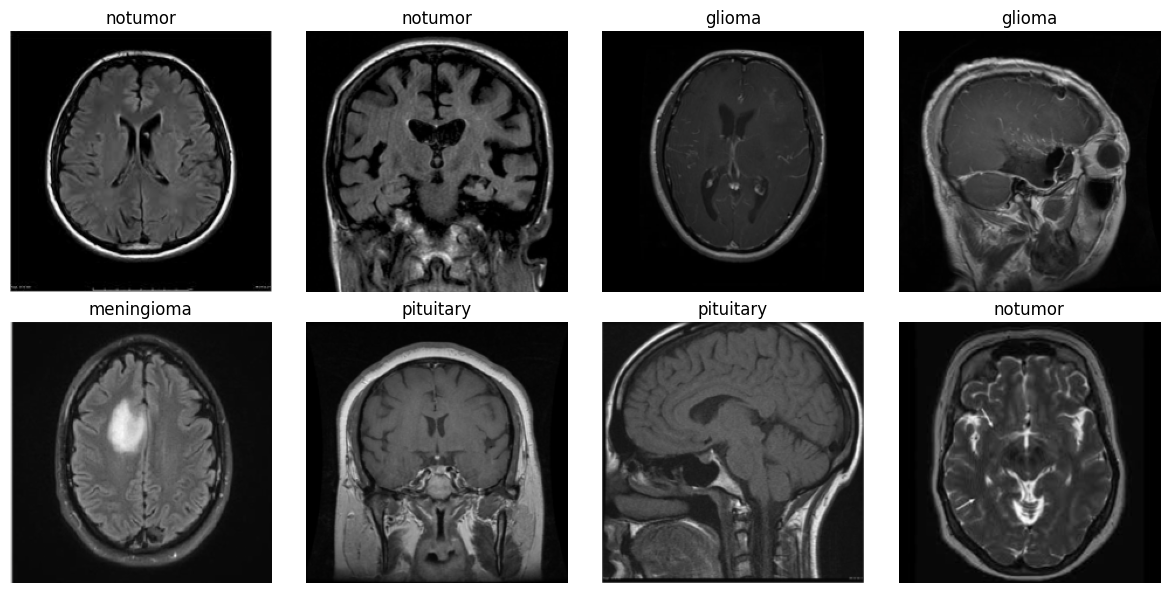

In [13]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1,2,0).numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
from collections import Counter

targets = [label for _, label in full_train_dataset.samples]
count = Counter(targets)

for idx, n in count.items():
    print(f"{class_names[idx]}: {n}")

glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400


In [15]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet50_Weights

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [17]:
class BrainResNet50(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        # Load pretrained ResNet50
        backbone = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V2
        )

        self.backbone = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        # Embedding Size
        self.embedding_dim = 2048

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        features = self.backbone(x)

        embedding = torch.flatten(features, 1)

        logits = self.classifier(embedding)

        return logits, embedding

In [18]:
model = BrainResNet50(num_classes=4)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


In [19]:
print(model)

BrainResNet50(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv

In [20]:
for param in model.backbone.parameters():
    param.requires_grad = False

In [21]:
for param in model.classifier.parameters():
    param.requires_grad = True

In [22]:
trainable_params = 0
total_params = 0

for name, param in model.named_parameters():

    total_params += param.numel()

    if param.requires_grad:
        trainable_params += param.numel()
        print(f"Trainable: {name}")

print("-" * 50)
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Total Parameters: {total_params:,}")

Trainable: classifier.1.weight
Trainable: classifier.1.bias
Trainable: classifier.4.weight
Trainable: classifier.4.bias
--------------------------------------------------
Trainable Parameters: 1,051,140
Total Parameters: 24,559,172


In [23]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [26]:
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import accuracy_score
import copy

In [27]:
NUM_EPOCHS = 20

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

In [28]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    predictions = []
    labels = []

    pbar = tqdm(loader)

    for images, targets in pbar:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits, embeddings = model(images)

        loss = criterion(logits, targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        labels.extend(targets.cpu().numpy())

        pbar.set_description(f"Loss {loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(labels, predictions)

    return epoch_loss, epoch_acc

In [29]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    predictions = []
    labels = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)
            targets = targets.to(device)

            logits, embeddings = model(images)

            loss = criterion(logits, targets)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            labels.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(labels, predictions)

    return epoch_loss, epoch_acc

In [30]:
import torch

class EarlyStopping:

    def __init__(self, patience=7, min_delta=0.0, save_path="best_model.pth"):

        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path

        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

            torch.save(model.state_dict(), self.save_path)

            print(f"✅ Validation Loss Improved: {val_loss:.4f}")
            print("Model Saved.")

        else:

            self.counter += 1

            print(f"No Improvement ({self.counter}/{self.patience})")

            if self.counter >= self.patience:

                self.early_stop = True

In [31]:
early_stopping = EarlyStopping(
    patience=7,
    min_delta=1e-4,
    save_path="best_resnet50_baseline.pth"
)

In [ ]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-"*50)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    # -----------------------------
    # Save Best Model (Validation Accuracy)
    # -----------------------------
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

        print(" New Best Accuracy!")

    early_stopping(val_loss, model)

    if early_stopping.early_stop:

        print("=" * 50)
        print(" Early Stopping Triggered")
        print("=" * 50)

        break


Epoch 1/20
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/158 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2cb41149a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2cb41149a0>
Traceback (most recent call las

Train Loss : 0.9132
Train Acc  : 0.7512
Val Loss   : 0.5649
Val Acc    : 0.8393
 New Best Accuracy!
✅ Validation Loss Improved: 0.5649
Model Saved.

Epoch 2/20
--------------------------------------------------


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train Loss : 0.4826
Train Acc  : 0.8508
Val Loss   : 0.4207
Val Acc    : 0.8554
 New Best Accuracy!
✅ Validation Loss Improved: 0.4207
Model Saved.

Epoch 3/20
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/158 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2cb41149a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c2cb41149a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

In [ ]:
model.load_state_dict(
    torch.load(
        "best_resnet50_baseline.pth",
        map_location=device
    )
)

print(" Best model loaded.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
def evaluate_model(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []
    all_embeddings = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits, embeddings = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
            all_probabilities.extend(probs.cpu().numpy())
            all_embeddings.extend(embeddings.cpu().numpy())

    results = {

        "loss": running_loss / len(loader.dataset),

        "accuracy": accuracy_score(all_labels, all_predictions),

        "precision": precision_score(
            all_labels,
            all_predictions,
            average="weighted"
        ),

        "recall": recall_score(
            all_labels,
            all_predictions,
            average="weighted"
        ),

        "f1": f1_score(
            all_labels,
            all_predictions,
            average="weighted"
        ),

        "labels": np.array(all_labels),

        "predictions": np.array(all_predictions),

        "probabilities": np.array(all_probabilities),

        "embeddings": np.array(all_embeddings)

    }

    return results

In [ ]:
results = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

In [ ]:
print("="*50)

print(f"Test Loss      : {results['loss']:.4f}")

print(f"Accuracy       : {results['accuracy']:.4f}")

print(f"Precision      : {results['precision']:.4f}")

print(f"Recall         : {results['recall']:.4f}")

print(f"F1 Score       : {results['f1']:.4f}")

print("="*50)

In [ ]:
class_names = test_dataset.classes

print(
    classification_report(
        results["labels"],
        results["predictions"],
        target_names=class_names,
        digits=4
    )
)

In [ ]:
cm = confusion_matrix(
    results["labels"],
    results["predictions"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(7,7))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()

##Feature Map Extraction

In [ ]:
activation = {}

def get_activation(name):

    def hook(model, input, output):

        activation[name] = output.detach().cpu()

    return hook


hooks = []

hooks.append(
    model.backbone[0].register_forward_hook(
        get_activation("conv1")
    )
)

hooks.append(
    model.backbone[4].register_forward_hook(
        get_activation("layer1")
    )
)

hooks.append(
    model.backbone[5].register_forward_hook(
        get_activation("layer2")
    )
)

hooks.append(
    model.backbone[6].register_forward_hook(
        get_activation("layer3")
    )
)

hooks.append(
    model.backbone[7].register_forward_hook(
        get_activation("layer4")
    )
)

In [ ]:
class FeatureExtractor:

    def __init__(self,
                 model,
                 device):

        self.model = model
        self.device = device

    def extract(self, image):

        self.model.eval()

        activation.clear()

        image = image.unsqueeze(0).to(self.device)

        with torch.no_grad():

            logits, embedding = self.model(image)

            probability = torch.softmax(
                logits,
                dim=1
            )

            prediction = torch.argmax(
                probability,
                dim=1
            )

        return {

            "conv1": activation["conv1"],

            "layer1": activation["layer1"],

            "layer2": activation["layer2"],

            "layer3": activation["layer3"],

            "layer4": activation["layer4"],

            "embedding": embedding.cpu(),

            "prediction": prediction.cpu(),

            "probability": probability.cpu()

        }

In [ ]:
extractor = FeatureExtractor(
    model,
    device
)

In [ ]:
image, label = test_dataset[0]

features = extractor.extract(image)

In [ ]:
for key, value in features.items():

    if torch.is_tensor(value):

        print(key, value.shape)

    else:

        print(key, value)

In [ ]:
all_features = []

for image, label in test_dataset:

    sample = extractor.extract(image)

    sample["label"] = label

    all_features.append(sample)

##Layer-wise Represenation Analysis

In [ ]:
import torch
import numpy as np

def compute_activation_statistics(feature_map):
    """
    feature_map shape:
    [1, C, H, W]
    """

    fmap = feature_map.squeeze(0)

    channels = fmap.shape[0]
    height = fmap.shape[1]
    width = fmap.shape[2]

    mean_activation = fmap.mean().item()

    std_activation = fmap.std().item()

    max_activation = fmap.max().item()

    sparsity = (fmap == 0).float().mean().item()

    return {

        "Channels": channels,

        "Resolution": f"{height}×{width}",

        "Mean": mean_activation,

        "Std": std_activation,

        "Max": max_activation,

        "Sparsity": sparsity

    }

In [ ]:
layers = [
    "conv1",
    "layer1",
    "layer2",
    "layer3",
    "layer4"
]

statistics = {}

for layer in layers:

    statistics[layer] = compute_activation_statistics(
        features[layer]
    )

In [ ]:
import pandas as pd

df = pd.DataFrame(statistics).T

df

In [ ]:
df["Mean"] = df["Mean"].round(4)
df["Std"] = df["Std"].round(4)
df["Max"] = df["Max"].round(4)
df["Sparsity"] = (100 * df["Sparsity"]).round(2)

df.rename(
    columns={
        "Sparsity": "Sparsity (%)"
    },
    inplace=True
)

df

##Mean Representation

In [ ]:
from collections import defaultdict

def get_correct_samples(labels,
                        predictions,
                        num_samples=20):

    selected = defaultdict(list)

    for idx, (label, pred) in enumerate(zip(labels, predictions)):

        if label == pred:

            if len(selected[label]) < num_samples:

                selected[label].append(idx)

    return selected

In [ ]:
selected_samples = get_correct_samples(
    labels,
    predictions,
    num_samples=20
)

In [ ]:
import torch

def compute_class_mean_representation(
    dataset,
    extractor,
    sample_indices,
    layer_name
):

    feature_maps = []

    for idx in sample_indices:

        image, _ = dataset[idx]

        features = extractor.extract(image)

        fmap = features[layer_name].squeeze(0)

        feature_maps.append(fmap)

    feature_maps = torch.stack(feature_maps)

    mean_feature = feature_maps.mean(dim=0)

    mean_activation = mean_feature.mean(dim=0)

    return mean_activation.numpy()

In [ ]:
class_mean_maps = {}

for class_id in range(len(class_names)):

    class_mean_maps[class_names[class_id]] = \
        compute_class_mean_representation(
            dataset=test_dataset,
            extractor=extractor,
            sample_indices=selected_samples[class_id],
            layer_name="layer3"
        )

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20,5)
)

for ax, class_name in zip(axes, class_names):

    ax.imshow(
        class_mean_maps[class_name],
        cmap="viridis"
    )

    ax.set_title(class_name)

    ax.axis("off")

plt.suptitle(
    "Layer3 Mean Representation",
    fontsize=18
)

plt.tight_layout()

plt.show()

##Evolution of Representation

In [ ]:
def summarize_layer(feature_map):
    """
    feature_map:
    [1,C,H,W]
    """

    fmap = feature_map.squeeze(0)

    # Mean
    mean_map = fmap.mean(dim=0)

    # Max
    max_map = fmap.max(dim=0)[0]

    # Top Activated Channel
    scores = fmap.mean(dim=(1,2))
    top_channel = torch.argmax(scores)

    top_map = fmap[top_channel]

    return (
        mean_map.numpy(),
        max_map.numpy(),
        top_map.numpy(),
        top_channel.item()
    )

In [ ]:
layers = [
    "conv1",
    "layer1",
    "layer2",
    "layer3",
    "layer4"
]

summaries = {}

for layer in layers:

    summaries[layer] = summarize_layer(
        features[layer]
    )

In [ ]:
fig, axes = plt.subplots(
    len(layers),
    4,
    figsize=(14,18)
)

# ستون اول
axes[0,0].imshow(
    image.permute(1,2,0)
)
axes[0,0].set_title("Input MRI")
axes[0,0].axis("off")

for i, layer in enumerate(layers):

    mean_map, max_map, top_map, ch = summaries[layer]

    # Mean
    axes[i,1].imshow(mean_map,cmap="viridis")
    axes[i,1].set_title(f"{layer}\nMean")
    axes[i,1].axis("off")

    # Max
    axes[i,2].imshow(max_map,cmap="viridis")
    axes[i,2].set_title("Max")
    axes[i,2].axis("off")

    # Top Channel
    axes[i,3].imshow(top_map,cmap="viridis")
    axes[i,3].set_title(f"Top Ch {ch}")
    axes[i,3].axis("off")

plt.tight_layout()

plt.show()

##Top Channels

In [ ]:
import torch

def get_top_channels(feature_map,
                     top_k=16):
    """
    feature_map:
    [1,C,H,W]
    """

    fmap = feature_map.squeeze(0)

    # میانگین هر کانال
    scores = fmap.mean(dim=(1,2))

    values, indices = torch.topk(
        scores,
        k=top_k
    )

    return indices, values

In [ ]:
def visualize_top_channels(feature_map,
                           top_k=16,
                           layer_name="Layer4"):

    fmap = feature_map.squeeze(0)

    indices, values = get_top_channels(
        feature_map,
        top_k
    )

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(10,10)
    )

    axes = axes.flatten()

    for ax, idx, score in zip(
        axes,
        indices,
        values
    ):

        ax.imshow(
            fmap[idx].numpy(),
            cmap="viridis"
        )

        ax.set_title(
            f"Ch {idx.item()}\n{score:.2f}",
            fontsize=9
        )

        ax.axis("off")

    plt.suptitle(
        f"{layer_name}\nTop {top_k} Activated Channels",
        fontsize=18
    )

    plt.tight_layout()

    plt.show()

In [ ]:
visualize_top_channels(
    features["layer4"],
    top_k=16,
    layer_name="Layer4"
)

In [ ]:
indices, values = get_top_channels(
    features["layer4"],
    top_k=16
)

for rank, (idx, score) in enumerate(
    zip(indices, values),
    start=1
):

    print(
        f"{rank:2d}. "
        f"Channel {idx.item():4d} "
        f"Activation = {score.item():.4f}"
    )

##Channel similarity

In [ ]:
indices, scores = get_top_channels(
    features["layer4"],
    top_k=64
)

In [ ]:
import torch

layer4 = features["layer4"].squeeze(0)

selected_maps = layer4[indices]

print(selected_maps.shape)

In [ ]:
vectors = selected_maps.view(
    selected_maps.shape[0],
    -1
)

print(vectors.shape)

In [ ]:
import torch.nn.functional as F

vectors = F.normalize(
    vectors,
    p=2,
    dim=1
)

similarity = vectors @ vectors.T

print(similarity.shape)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(
    similarity.cpu().numpy(),
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Cosine Similarity")

plt.title("Layer4 Channel Similarity")

plt.xlabel("Channel")

plt.ylabel("Channel")

plt.show()

##Representation Compression

In [ ]:
import pandas as pd

layers = [
    "conv1",
    "layer1",
    "layer2",
    "layer3",
    "layer4"
]

rows = []

for layer in layers:

    fmap = features[layer].squeeze(0)

    C, H, W = fmap.shape

    rows.append({

        "Layer": layer,

        "Channels": C,

        "Height": H,

        "Width": W,

        "Spatial Size": H * W,

        "Feature Dimension": C * H * W

    })

representation_df = pd.DataFrame(rows)

representation_df

In [ ]:
initial_size = representation_df.loc[0, "Spatial Size"]

representation_df["Compression Ratio"] = (
    initial_size /
    representation_df["Spatial Size"]
)

representation_df

In [ ]:
initial_channels = representation_df.loc[0, "Channels"]

representation_df["Channel Growth"] = (
    representation_df["Channels"] /
    initial_channels
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    representation_df["Layer"],
    representation_df["Spatial Size"],
    marker="o",
    linewidth=3
)

plt.title("Spatial Resolution Compression")

plt.ylabel("Spatial Size")

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    representation_df["Layer"],
    representation_df["Channels"],
    marker="o",
    linewidth=3
)

plt.title("Channel Expansion")

plt.ylabel("Channels")

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    representation_df["Layer"],
    representation_df["Feature Dimension"],
    marker="o",
    linewidth=3
)

plt.title("Representation Size")

plt.ylabel("Total Features")

plt.grid(True)

plt.show()

In [ ]:
print("="*60)
print("Representation Compression Analysis")
print("="*60)

for _, row in representation_df.iterrows():

    print(f"{row['Layer']}")

    print(f"Channels            : {row['Channels']}")

    print(f"Spatial Resolution  : {row['Height']} × {row['Width']}")

    print(f"Compression Ratio   : {row['Compression Ratio']:.1f}x")

    print(f"Channel Growth      : {row['Channel Growth']:.1f}x")

    print("-"*40)

##Embedding Analysis

In [ ]:
import numpy as np

embeddings = np.load("embeddings.npy")
labels = np.load("labels.npy")
predictions = np.load("predictions.npy")
probabilities = np.load("probabilities.npy")

print(embeddings.shape)

In [ ]:
!pip install umap-learn

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
reducer = umap.UMAP(

    n_neighbors=15,

    min_dist=0.1,

    n_components=2,

    metric="euclidean",

    random_state=42

)

embedding_2d = reducer.fit_transform(
    embeddings
)

print(embedding_2d.shape)

In [ ]:
class_names = [

    "Glioma",

    "Meningioma",

    "No Tumor",

    "Pituitary"

]

In [ ]:
plt.figure(figsize=(10,8))

for i in range(4):

    mask = labels == i

    plt.scatter(

        embedding_2d[mask,0],

        embedding_2d[mask,1],

        s=18,

        alpha=0.75,

        label=class_names[i]

    )

plt.title("UMAP of ResNet50 Embeddings")

plt.xlabel("UMAP-1")

plt.ylabel("UMAP-2")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
correct = labels == predictions

plt.figure(figsize=(10,8))

plt.scatter(

    embedding_2d[correct,0],

    embedding_2d[correct,1],

    s=15,

    alpha=0.5,

    label="Correct"

)

plt.scatter(

    embedding_2d[~correct,0],

    embedding_2d[~correct,1],

    s=35,

    marker="x",

    label="Incorrect"

)

plt.legend()

plt.title("Correct vs Incorrect Predictions")

plt.show()

In [ ]:
confidence = probabilities.max(axis=1)

plt.figure(figsize=(10,8))

plt.scatter(

    embedding_2d[:,0],

    embedding_2d[:,1],

    c=confidence,

    cmap="viridis",

    s=18

)

plt.colorbar(label="Prediction Confidence")

plt.title("UMAP Colored by Confidence")

plt.show()